# Metagenomic Analysis: The Global Gut Microbiome
### PA 1 – Applied Digital Life Sciences – Digital Health
**Authors:** Ajna Binaki, Dario Filippone, Peter Pan, Naruto, Gojo, Sukuna

## Introduction
Write text here.

## 1. Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

In [3]:
path_metadata      = '../data/raw/Human_atlas/sampleID.csv'
path_microbiome_raw = '../data/raw/Human_atlas/vect_atlas.csv'

metadata      = pd.read_csv(path_metadata)
microbiome_raw = pd.read_csv(path_microbiome_raw, index_col=0)

microbiome    = microbiome_raw.transpose()
combined_data = pd.merge(metadata, microbiome, left_on='sample.ID', right_index=True, how='inner')

print(f"Dataset shape: {combined_data.shape[0]} samples, {combined_data.shape[1]} columns")
combined_data.to_csv('../data/processed/01_combined_data.csv', index=False)

display(combined_data.head())

Dataset shape: 6014 samples, 2004 columns


,sample.ID,BioProject,type,Age,Gender,BMI,Geography,Sequencer,MgsRichness,GeneRichness,...,msp_2176,msp_2178,msp_2180,msp_2191,msp_2195,msp_2196,msp_2207,msp_2209,msp_2210,msp_2211
0,ERS608599,PRJEB7774,Disease,64.0,Male,29.0,Austria,Illumina HiSeq 2000,184,563013,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERS608499,PRJEB7774,Control,68.0,Male,32.0,Austria,Illumina HiSeq 2000,265,686859,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERS608489,PRJEB7774,Control,60.0,Female,22.0,Austria,Illumina HiSeq 2000,228,616715,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERS608554,PRJEB7774,Disease,70.0,Male,34.0,Austria,Illumina HiSeq 2000,236,628862,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERS608521,PRJEB7774,Control,68.0,Male,23.0,Austria,Illumina HiSeq 2000,254,627031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Demographics
Overview of sample distribution by country and health status.

In [4]:
combined_data["type"] = combined_data["type"].astype("category")

healthy_data = combined_data[combined_data["type"] == "Control"]
disease_data = combined_data[combined_data["type"] == "Disease"]

print(f"Total samples:  {len(combined_data)}")
print(f"  Healthy:      {len(healthy_data)}")
print(f"  Disease:      {len(disease_data)}")

Total samples:  6014
  Healthy:      3292
  Disease:      2713


In [5]:
# Samples per country, split by health status
country_type = (
    combined_data
    .groupby(["Geography", "type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .assign(Total=lambda df: df.sum(axis=1))
    .sort_values("Total", ascending=False)
)

print("--- Samples per Country ---")
print(country_type.to_string())

--- Samples per Country ---
type        Control  Disease  Total
Geography                          
China           730     1018   1748
USA             666      242    908
Japan           291      353    644
France           61      314    375
UK              259       90    349
Denmark         335        0    335
Spain            14      188    202
Fiji            193        0    193
Italy            63      129    192
Germany          93       91    184
Sweden           58      114    172
Austria          63       93    156
India           110       30    140
Madagascar      112        0    112
Mongolia        110        0    110
Luxembourg       52       47     99
Peru             36        0     36
Tanzania         27        0     27
Thailand         15        0     15
Finland           4        4      8


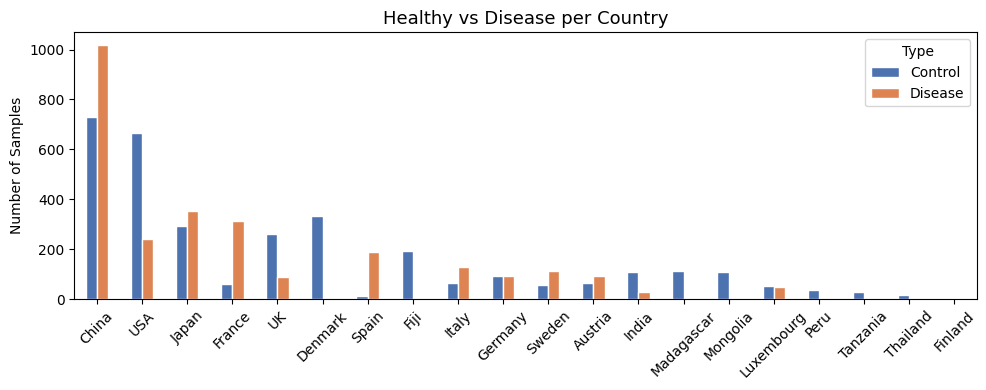

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

country_type[["Control", "Disease"]].plot(
    kind="bar", ax=ax,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)

ax.set_title("Healthy vs Disease per Country", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type")
plt.tight_layout()
plt.show()

# 4. Preprocessing

Before applying analytical methods or machine learning pipelines, raw metagenomic data must undergo rigorous preprocessing to account for its unique mathematical properties. Bacterial abundance tables are inherently **sparse** and **compositional**, with a hight zero-inflation. This sparsity arises because individual samples only contain a specific subset of the global microbial diversity, and limited sequencing depth, often referred to as **sampling effort**, can lead to a failure in capturing rare taxa. [Knights et al. (2018)](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf)

## Metadata and Feature Description

| Column        | Description |
|--------------|------------|
| `sample.ID`  | Unique identifier per sample. |
| `BioProject` | Source study; used to identify and mitigate potential **batch effects**. |
| `type`       | Binary classification: Control (healthy) vs. Disease. |
| `Age` / `Gender` | Demographic covariates used for cohort matching. |
| `BMI`        | Body Mass Index; the primary phenotypic variable for obesity analysis. |
| `Geography`  | Country of origin; a major driver of microbial variance. |
| `MgsRichness`| Alpha-diversity metric (Species Richness) per sample. |
| `msp_XXXX`   | Metagenomic Species Pangenome (MSP) relative abundance. |

---

## Preprocessing Workflow

To ensure a robust comparison between geographical cohorts and phenotypes, the following pipeline was implemented based on established best practices according to [Knights et al. (2018)](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf) and [Gregory B. gloor(2017)](../Papers/GregoryBGloor2017.pdf)

### 1. Quality and Prevalence Filtering

Following the recommendation to control for technical variation and sequencing errors, filtering was performed prior to normalization.

- **Sample Filtering (Richness):** Following the recommendation to exclude samples (rarefraction) with insufficient sampling effort, we excluded samples in the lowest 5th percentile of richness to remove technical artifacts. This ensures that only samples with sufficient "sampling effort" are compared, as extremely low richness typically indicates technical artifacts or poor DNA yield. [Knights et al. (2018), Chapter 3](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf)

- **Taxa Filtering (Prevalence):** MSPs present in fewer than 10% of samples were removed. This step is crucial because most apparent sequence diversity in marker gene and metagenomic data often arises from sequencing errors. [Knights et al. (2018), Chapter 3](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf). Additionaly, this step reduces sparsity, which makes it more suited for downstream ML applications and by focusing on stable microbial signatures we gain more predictible and reproducible insights.


### 2. Normalization: Total Sum Scaling (TSS)

To account for varying sequencing depths across different library preparations, counts were normalized to relative abundances. Each sample was divided by its row sum so that the features sum to 1.0:

$$
x_{rel} = \frac{x_i}{\sum x_i}
$$

While this makes samples comparable regardless of original scale, it reinforces the compositional nature of the data, where features are no longer independent. In this setup, an increase in one species' proportion mathematically forces others to decrease, even if their true abundance is stable. This artificial dependency often triggers spurious correlations that can mislead standard statistical analyses. [Gregory B. gloor(2017)](../Papers/GregoryBGloor2017.pdf)

### 3. Transformation: Centered Log-Ratio (CLR)

To move the data from the Aitchison simplex into Euclidean space, we applied the **Centered Log-Ratio (CLR)** transformation. This transformation is "compositionally aware" and allows for the application of standard statistical tools like PCA and Random Forest without the biases inherent in proportional data.

The CLR is calculated as:

$$
CLR(x) = \left[ \ln \frac{x_1}{g(x)}, \dots, \ln \frac{x_n}{g(x)} \right]
$$

where $g(x)$ represents the geometric mean of the abundances within the sample. [Gregory B. gloor(2017)](../Papers/GregoryBGloor2017.pdf)

In [7]:
# --- Configuration & Constants ---
RICHNESS_Q = 0.05
PREVALENCE_T = 0.10

# Initial Filtering: Extract Healthy Cohort
# Frop Type column
healthy_df = combined_data[combined_data["type"] == "Control"].drop(columns=["type"]).copy()

# Identify Column Groups
msp_cols = [c for c in healthy_df.columns if c.startswith('msp')]
meta_cols = [c for c in healthy_df.columns if not c.startswith('msp')]

# Sample Filtering (Richness)
# Calculate richness for each sample (number of MSPs with abundance > 0)
richness = healthy_df[msp_cols].gt(0).sum(axis=1)
richness_threshold = richness.quantile(RICHNESS_Q)

filtered_df = healthy_df[richness >= richness_threshold].copy()

# Pravalence Filtering, Remove MSPs that are present in less than 10% of samples
prevalence = (filtered_df[msp_cols] > 0).mean()
keep_msps = prevalence[prevalence >= PREVALENCE_T].index.tolist()

# Assembly of Dataset
final_data = filtered_df[meta_cols + keep_msps]

# Save output
final_data.to_csv('../data/processed/03_filtered_healthy_data.csv', index=False)

# Checking the results
print(f"Shape:    {final_data.shape}")
print(f"Taxa:     {len(keep_msps)} kept from {len(msp_cols)}")
print(f"Min Prev: {(final_data[keep_msps] > 0).mean().min():.1%}")
print(f"Richness: {final_data[keep_msps].gt(0).sum(axis=1).min()} to {final_data[keep_msps].gt(0).sum(axis=1).max()}")



Shape:    (3128, 609)
Taxa:     596 kept from 1990
Min Prev: 10.0%
Richness: 53 to 388


In [30]:
# Normalization (TSS)
normalized_df = final_data.copy()
normalized_df[keep_msps] = normalized_df[keep_msps].div(normalized_df[keep_msps].sum(axis=1), axis=0)
normalized_df.to_csv('../data/processed/04_normalized_healthy_data.csv', index=False)

# Calculatiing percentage of 0s after normalization
zero_percentage = (normalized_df[keep_msps] == 0).mean().mean()
print(f"Percentage of zeros after normalization: {zero_percentage:.1%}")

Percentage of zeros after normalization: 66.6%


In [31]:
# CLR Transformation
clr_df = normalized_df.copy()

log_data = np.log(clr_df[keep_msps] + 1e-6)
clr_df[keep_msps] = log_data.sub(log_data.mean(axis=1), axis=0)
clr_df.to_csv('../data/processed/05_clr_healthy_data.csv', index=False)

In [32]:
# 1. Quick Data Integrity Check
print(f" Data Checks for CLR-Transformed Data:")
print(f"NaN Values: {clr_df[keep_msps].isna().sum().sum()}")
print(f"Zero Values: {(clr_df[keep_msps] == 0).sum().sum()}")
print(f"Dimensions: {clr_df.shape[0]} Samples x {len(keep_msps)} MSPs")

 Data Checks for CLR-Transformed Data:
NaN Values: 0
Zero Values: 0
Dimensions: 3128 Samples x 596 MSPs


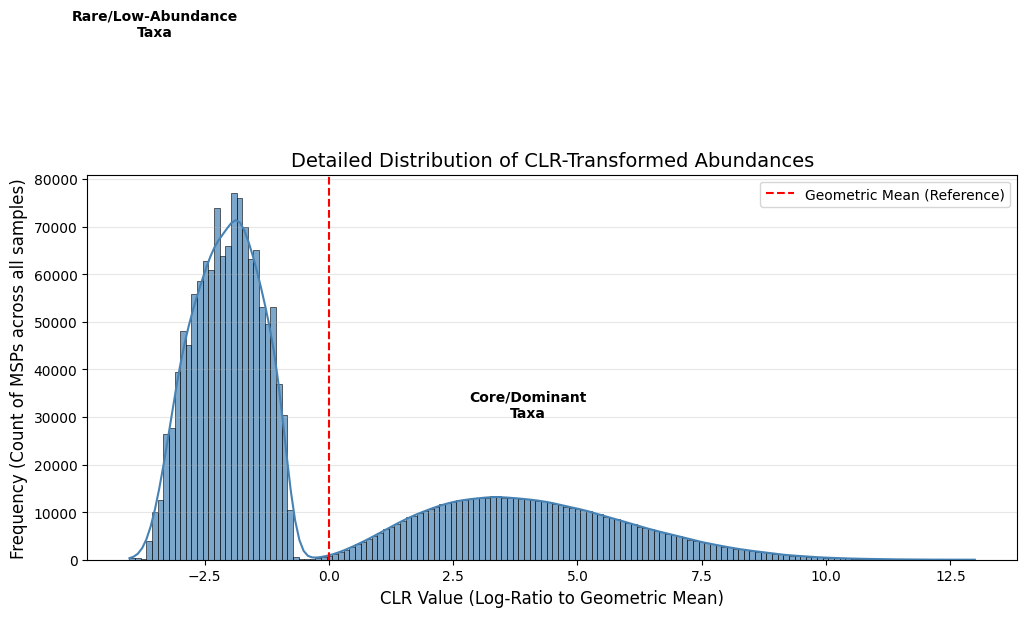

In [33]:
# Increase figure width for better detail (12x5 ratio)
plt.figure(figsize=(12, 5))

# Plot with higher bin count for more granularity
sns.histplot(clr_df[keep_msps].values.flatten(), bins=150, kde=True, color="steelblue", alpha=0.7)

# Add a vertical line at 0 (the Geometric Mean reference point)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label="Geometric Mean (Reference)")

# Add informative text labels for the 'mountains'
plt.text(-3.5, 110000, 'Rare/Low-Abundance\nTaxa', horizontalalignment='center', color='black', fontweight='bold')
plt.text(4, 30000, 'Core/Dominant\nTaxa', horizontalalignment='center', color='black', fontweight='bold')

plt.title("Detailed Distribution of CLR-Transformed Abundances", fontsize=14)
plt.xlabel("CLR Value (Log-Ratio to Geometric Mean)", fontsize=12)
plt.ylabel("Frequency (Count of MSPs across all samples)", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Run PCA on your CLR data
pca = PCA(n_components=2)
pcs = pca.fit_transform(clr_df[keep_msps])

# 2. Get Log-Library Size (Use your RAW counts table here!)
# Replace 'raw_counts_df' with the name of your dataframe before TSS/CLR
log_lib_size = np.log10(final_data[keep_msps].sum(axis=1))

# 3. Calculate Correlation (The "te Beest" Metric)
correlation = np.corrcoef(log_lib_size, pcs[:, 0])[0, 1]

# 4. Diagnostic Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=log_lib_size, y=pcs[:, 0], alpha=0.5)
plt.title(f"Library Size Bias Check\nCorrelation (R): {correlation:.3f}")
plt.xlabel("Log10 Library Size (Sequencing Depth)")
plt.ylabel("PC1 (Major Biological Variance)")
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.show()

print(f"Explained Variance of PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")

NameError: name 'raw_counts_df' is not defined